# Junction core block clustering and diversity
Cluster junction by core genome diversity and define insertions, deletions, translocations and inversions.

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist, plot_event_counts_distribution, plot_events_per_junction, plot_cluster_count_distribution, plot_event_length_distribution, plot_cluster_count_vs_diversity, plot_marginal_scatter, plot_all_junctions_pairwise_distances
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events

In [2]:
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq,tot_acc_len
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,18953,18189.108108,218,16280.0,1698.0,False,727.5,0.018018,1488
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,12516,11742.500000,221,1529.0,10210.0,False,777.0,0.004505,777
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,29386,27955.472973,221,23708.0,4241.0,False,1437.0,0.004505,1437
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,8141,7371.000000,220,2780.0,4584.0,False,777.0,0.009009,777
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,48231,10227.959459,221,7295.0,2761.0,False,38175.0,0.004505,38175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,105312,85545.500000,0,18605.0,29023.0,False,35067.5,1.000000,70135
544,EOBHADSLFU_f__SKPHAXSFLS_r,2,1,False,1,2,False,0.000000,1,7230,7230,7230.000000,2,7230.0,7230.0,True,NaN,0.000000,0
545,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,83629,83629.000000,2,31644.0,48920.0,False,NaN,0.000000,0
546,YUOECYBHUS_f__ZTHKZYHPIX_f,2,20,True,2,1,True,0.693147,35,66709,186025,126367.000000,0,60231.0,5710.0,False,60426.0,1.000000,109823


clustering_results = {}

for junction_id in jdf["edge"].tolist():
    print(junction_id)
    cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core(junction_id, plot_consensus=False, plot_pair_dist=False, plot_snp_dist= False, plot_ambiguities= False, clustering_bl_thresh=0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')
    clustering_results[junction_id] = cluster_map_core

    # determine insertions, deletions, inversions, translocations for each consensus path
    example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_id}.json")

    for i in range(1, len(consensus_paths_plotting) + 1):
        insertions, deletions, inversions, translocations = get_insertions_deletions_from_consensus(assignment_df_plotting, consensus_paths_plotting, path_dict, consensus = i)
        summarize_inversions_consensus(inversions, junction_id, example_pangraph, consensus_id = i, parent_dir = "../results/atb_lookup/inversions", save_df=True)
        summarize_translocations_consensus(translocations, junction_id, example_pangraph, consensus_id = i, parent_dir = "../results/atb_lookup/translocations", save_df=True)
        write_insertions_fasta(junction_id, example_pangraph, insertions, consensus = i, save_df=True)
        deletions_df = summarize_deletions_consensus(deletions, junction_id, example_pangraph, path_dict, assignment_df_plotting, consensus_id=i, parent_dir = "../results/atb_lookup/deletions", rerun_alignment=False, save_df=True)

    load_all_translocations_summaries("../results/atb_lookup/translocations", junction_id, save_df=True)
    load_all_insertions_summaries("../results/atb_lookup/insertions", junction_id, save_df=True)
    load_all_inversions_summaries("../results/atb_lookup/inversions", junction_id, save_df=True)
    load_all_deletions_summaries("../results/atb_lookup/deletions", junction_id, save_df=True)

cluster_df = cluster_map_to_dataframe(clustering_results, save_path="../results/consensus_analysis/cluster_maps.csv")


# 8 min after alignment has been prerun, more than an hour if core alignments have to be run

# Compute and save                                                            
dist_df = collect_all_pairwise_distances(junction_names = jdf.edge.tolist(), results_dir = "../results/",
save_path="distances.csv")

# 15 min

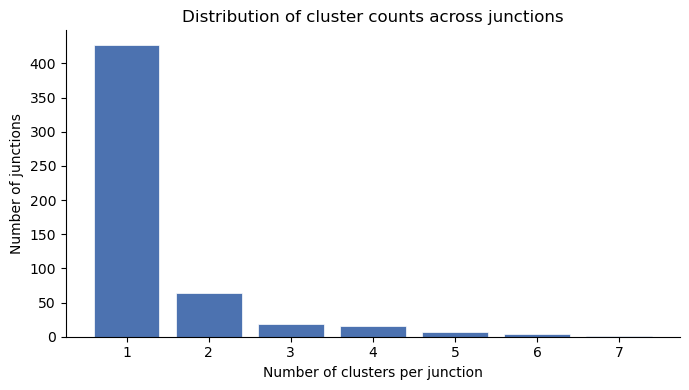

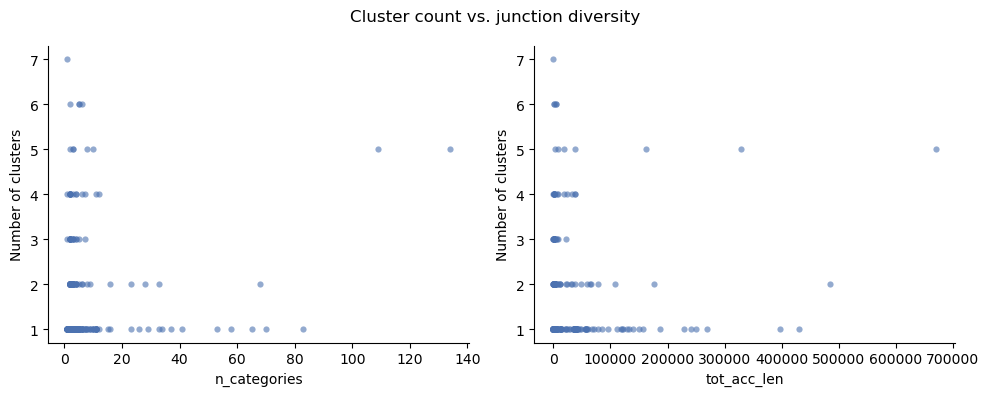

In [3]:
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps.csv")
cluster_df_filtered = cluster_df.copy()[cluster_df['n_isolates'] >= 200]
plot_cluster_count_distribution(cluster_df_filtered)
# TODO: add pangenome length, potentially block diversity
plot_cluster_count_vs_diversity(cluster_df_filtered, jdf, diversity_columns=["n_categories", "tot_acc_len"], figsize=(10,4))

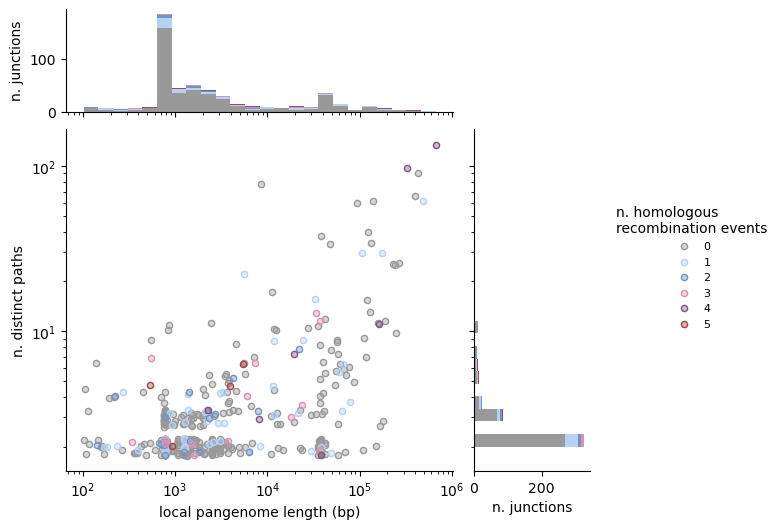

In [4]:
jdf_clusters = jdf.copy().merge(cluster_df.loc[:,['junction_name', 'n_clusters']], left_on="edge", right_on="junction_name", how="left")      

fig, axes = plot_marginal_scatter(
    jdf_clusters,
    x_col="tot_acc_len",
    y_col="n_categories",
    y_jitter_low=0.88,
    y_jitter_high=1.12,
    fill_alpha=0.4,
    edge_alpha=1,
    scatter_size=20,
    random_seed=42,
    point_linewidth=1,
    color_by_n_clusters=True,
    filter_y_gt_1 = True,
    filled = True
)
plt.show()

Loaded pairwise distances from distances.csv (13134776 rows).


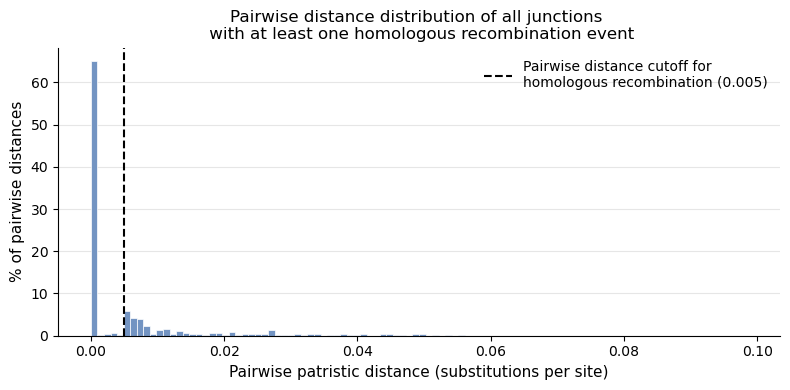

In [5]:
# Load instead of recomputing
dist_df = collect_all_pairwise_distances(junction_names = jdf.edge.tolist(), results_dir = "../results/",
load_path="distances.csv")

# Plot, optionally excluding some junctions
plot_all_junctions_pairwise_distances(dist_df, exclude = jdf_clusters[jdf_clusters['n_clusters'] == 1].edge.tolist(), vline=0.005, percentage=True, title="Pairwise distance distribution of all junctions \n with at least one homologous recombination event", figsize=(8,4))

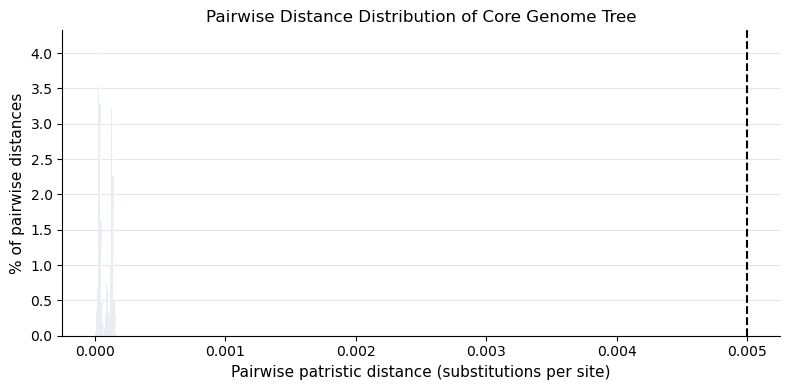

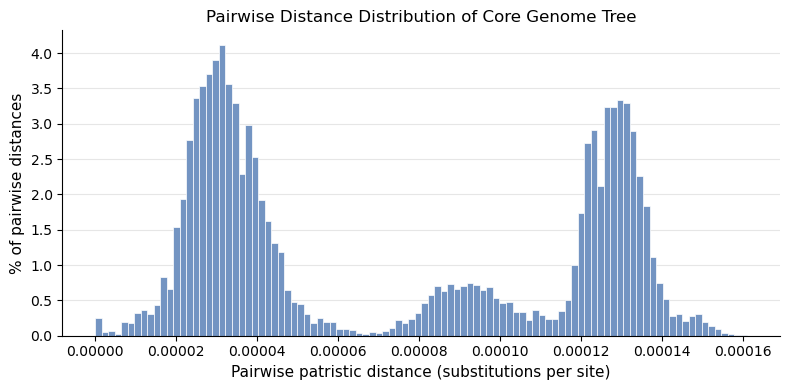

In [6]:
dists = compute_pairwise_distances('../config/polished_tree.nwk')
plot_pairwise_distance_hist(dists, bins=100, vline=0.005, vline_kwargs={"color": "black", "linestyle": "--"}, title="Pairwise Distance Distribution of Core Genome Tree", figsize=(8,4), percentage=True)
plot_pairwise_distance_hist(dists, bins=100, vline=None, vline_kwargs={"color": "black", "linestyle": "--"}, title="Pairwise Distance Distribution of Core Genome Tree", figsize=(8,4), percentage=True)

Saved insertions summary to ../results/atb_lookup/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup/deduplicated_events.csv
Saved event counts to ../results/atb_lookup/event_counts_per_junction.csv


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2026: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



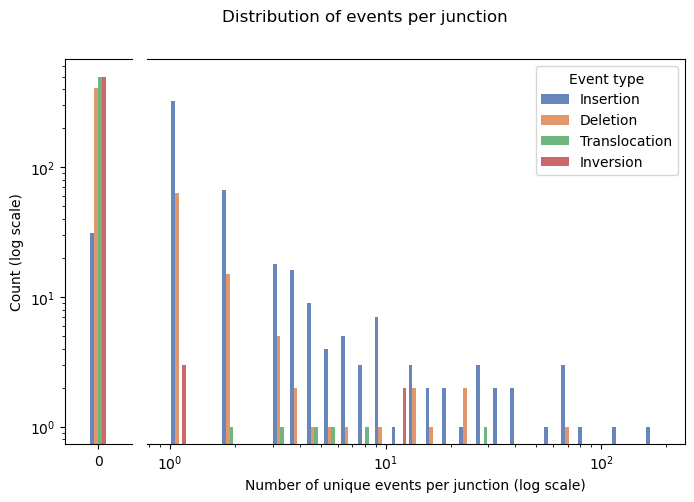

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2026: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



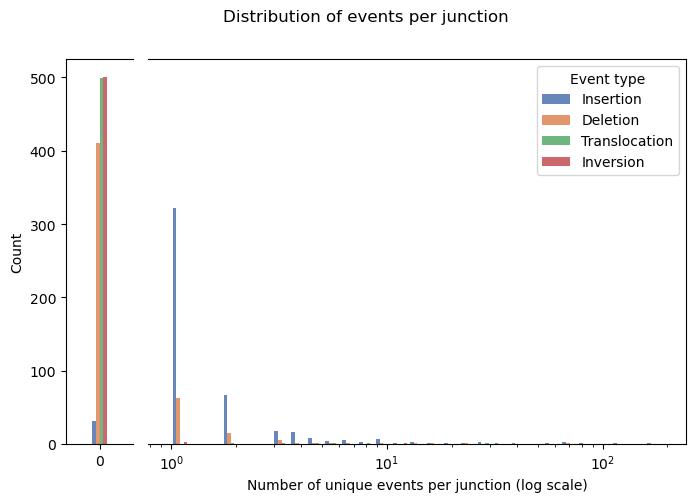

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:1893: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



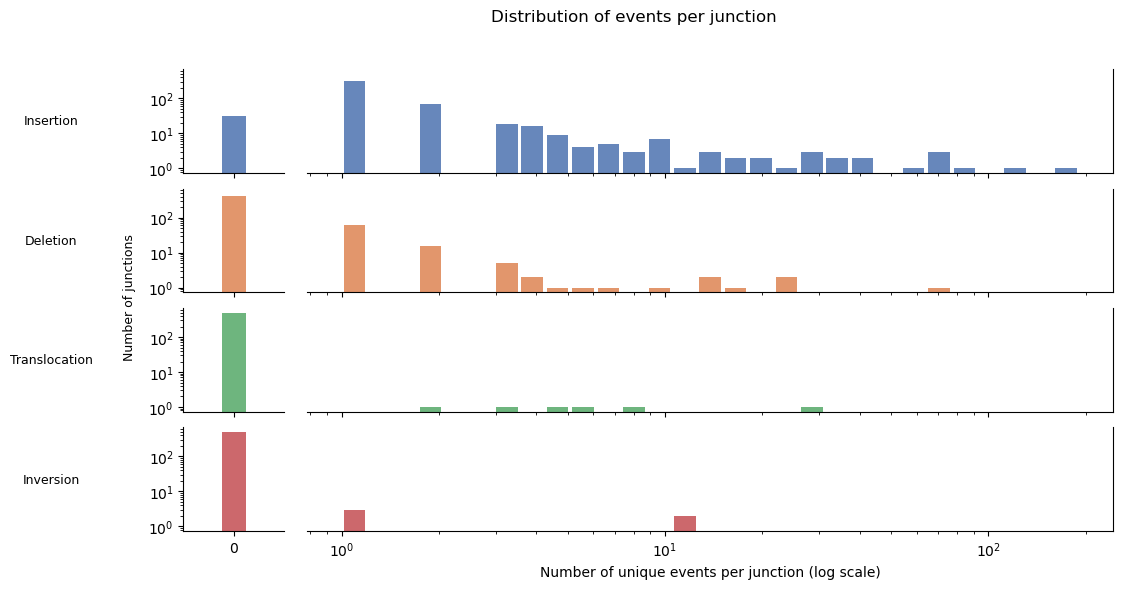

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:1893: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



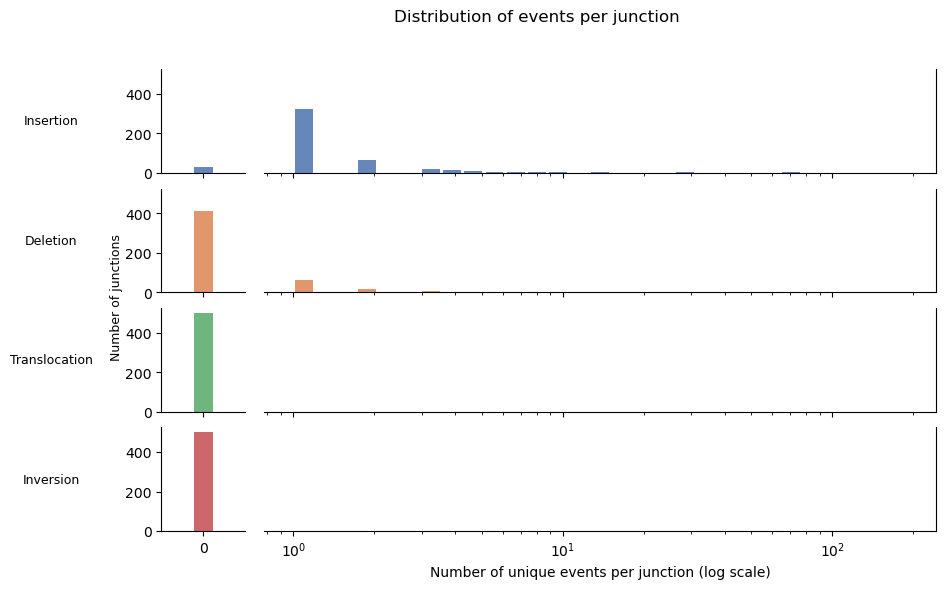

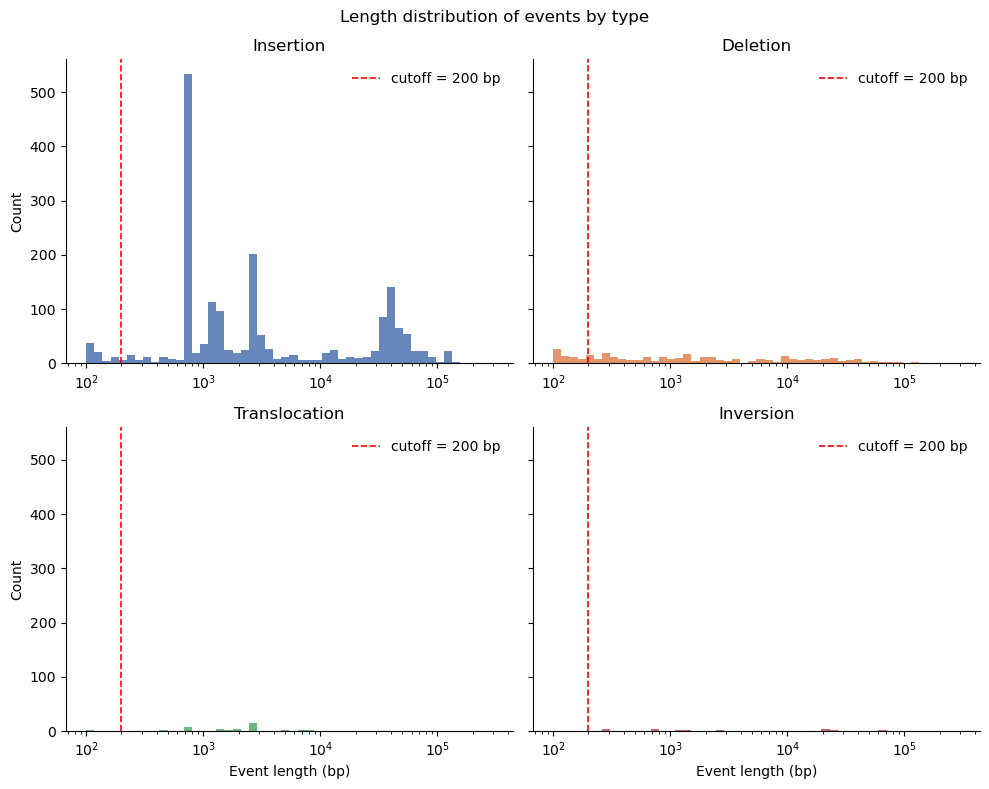

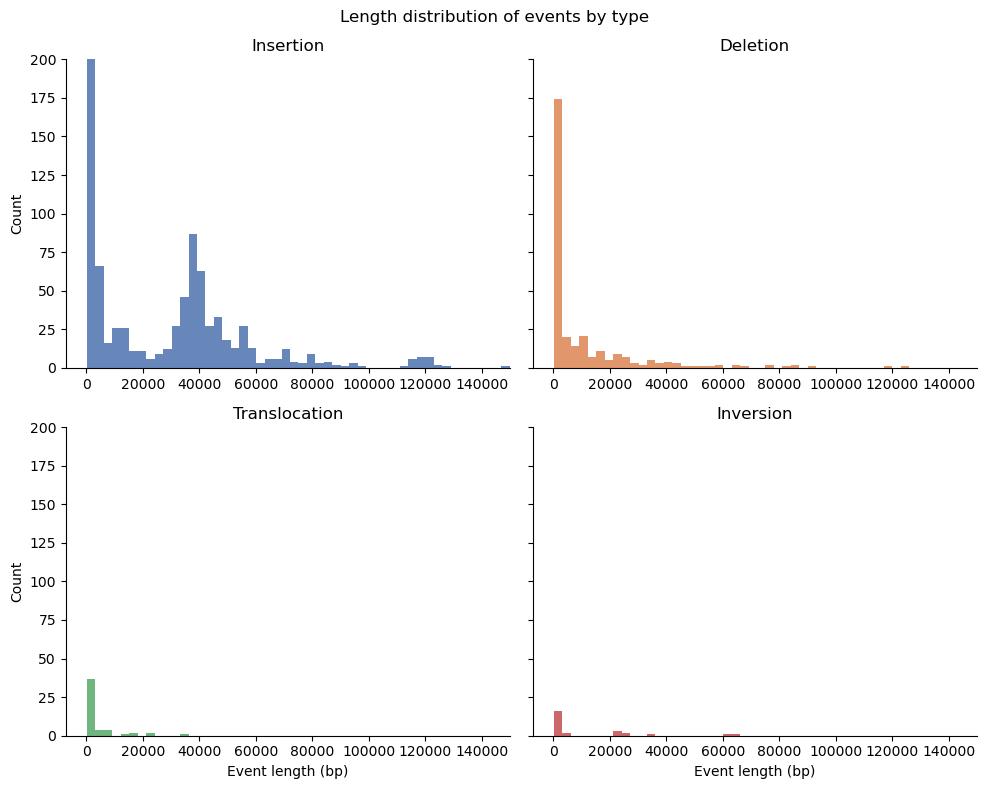

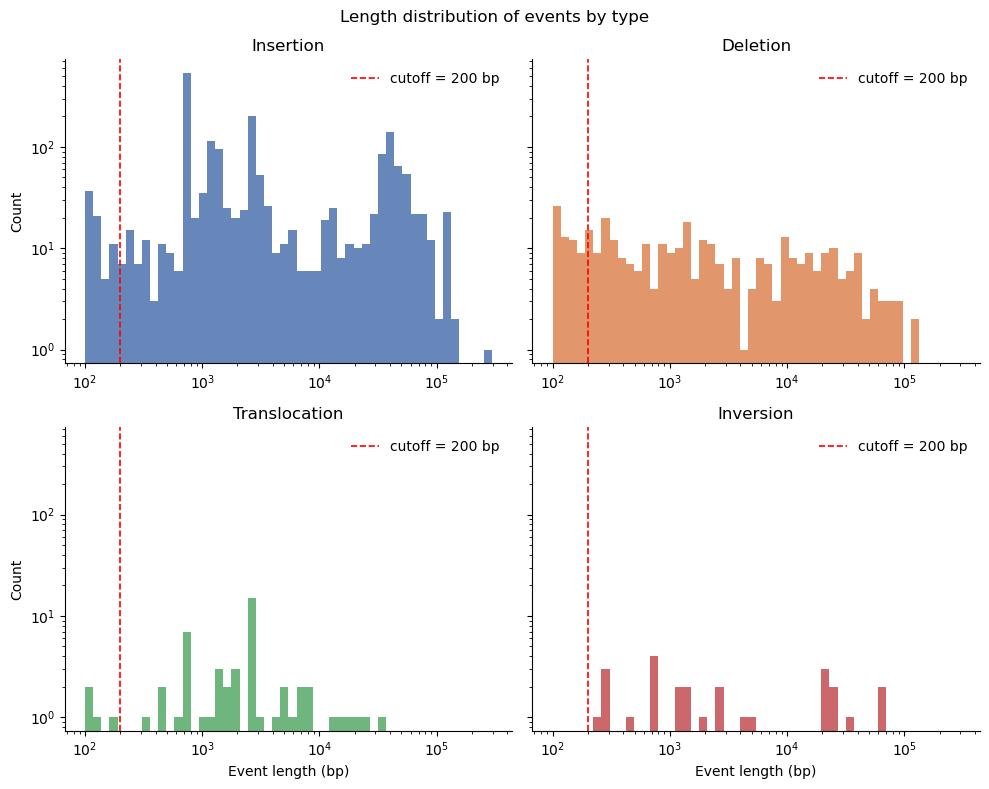

In [7]:
summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=True)
summary_df = deduplicate_events(summaries, save_path="../results/atb_lookup/deduplicated_events.csv")  
counts_df = count_events_per_junction(summary_df, min_length=200, save_path="../results/atb_lookup/event_counts_per_junction.csv")  

plot_event_counts_distribution(counts_df, figsize=(8, 5), log_x = True, log_y = True)
plot_event_counts_distribution(counts_df, figsize=(8, 5), log_x = True, log_y = False)
plot_event_counts_distribution(counts_df, figsize=(12, 6), log_x = True, log_y = True, subplots = True)
plot_event_counts_distribution(counts_df, figsize=(10, 6), log_x = True, log_y = False, subplots = True)

plot_event_length_distribution(summary_df, min_length_threshold=200, log_y = False, log_x=True)
plot_event_length_distribution(summary_df, min_length_threshold=200, log_y = False, log_x=False, y_max = 200, x_max = 150000, filter_below_threshold=True)
plot_event_length_distribution(summary_df, min_length_threshold=200, log_x = True)                                                                                                                                       


In [8]:
jdf_counts = jdf_clusters.merge(counts_df, on="junction_name", how="left")                                                                                                                              
jdf_counts[counts_df.columns.drop("junction_name")] = jdf_counts[counts_df.columns.drop("junction_name")].fillna(0)  

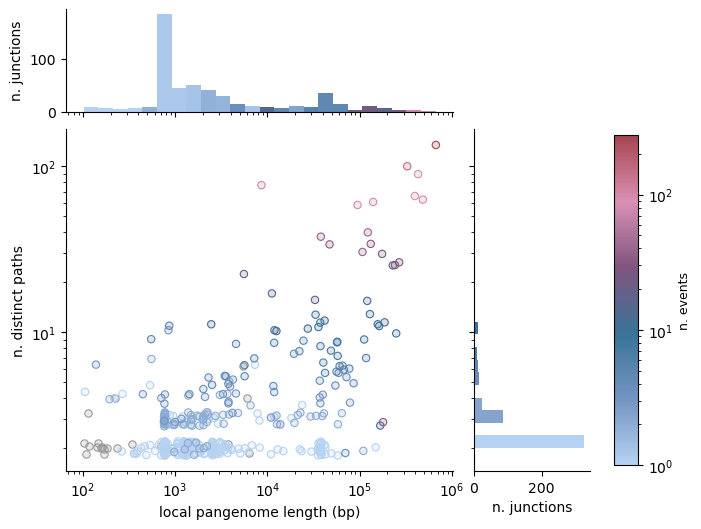

In [9]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_counts,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_events",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.2,
      edge_alpha=1,                                                                                                                                                                                       
  )    

# histogram colored by mean event count per bin

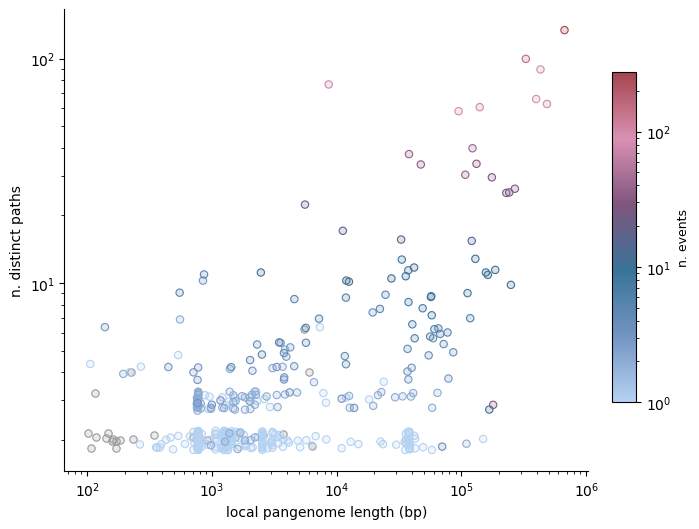

In [10]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_counts,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_events",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.2,
      edge_alpha=1,
      show_histograms=False                                                                                                                                                                                     
  )  

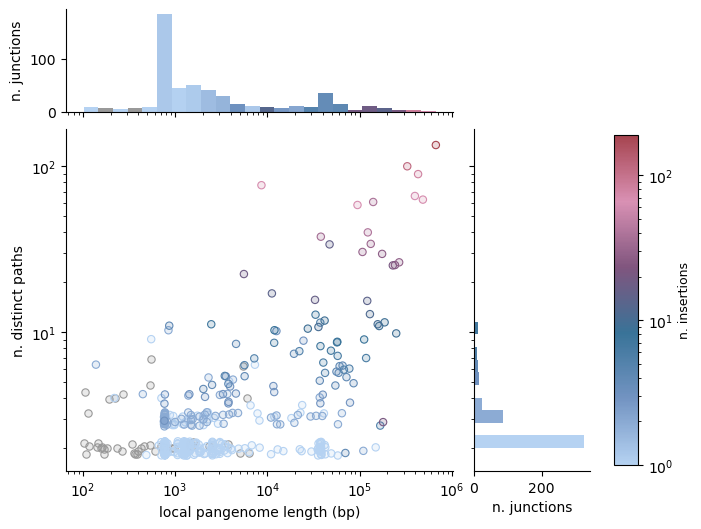

In [11]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_counts,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_insertion",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.2,
      edge_alpha=1,                                                                                                                                                                                       
  ) 

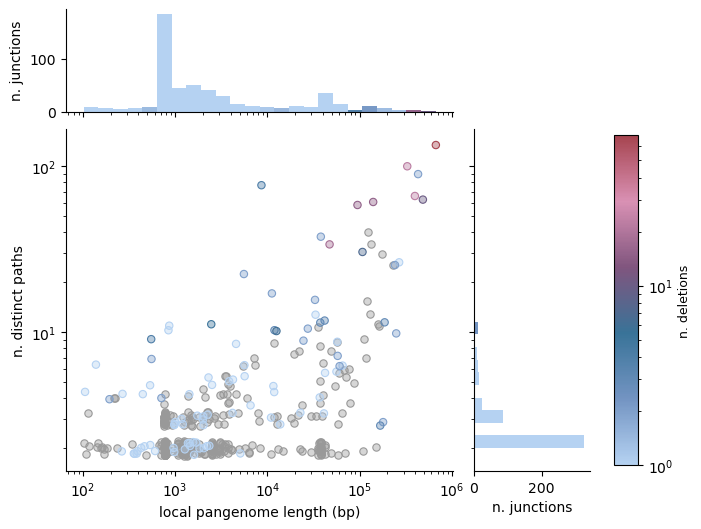

In [12]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_counts,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_deletion",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.4,
      edge_alpha=1,                                                                                                                                                                                       
  ) 

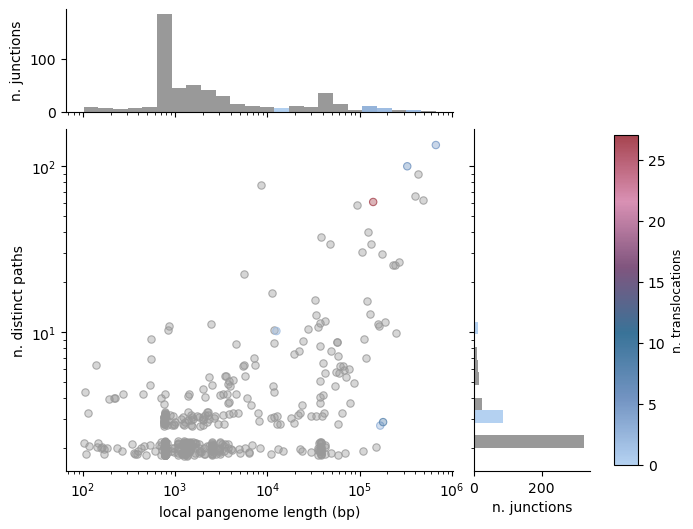

In [13]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_counts,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_translocation",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.4,
      edge_alpha=0.8,
      log_color_scale=False                                                                                                                                                                                
  ) 

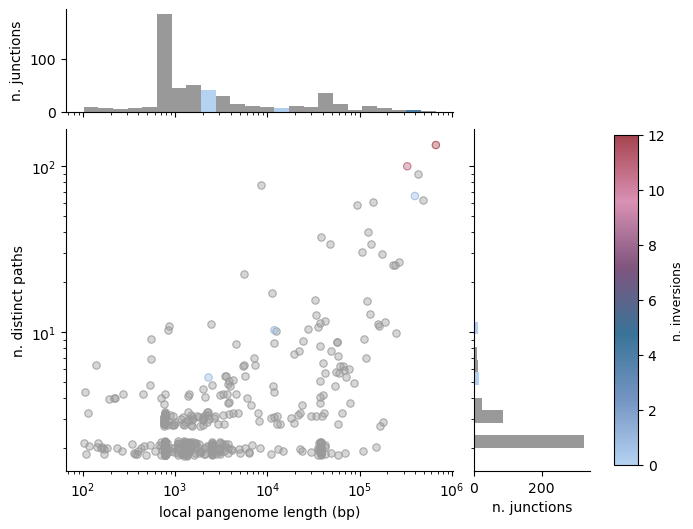

In [14]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_counts,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_inversion",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.4,
      edge_alpha=0.8,
      log_color_scale=False                                                                                                                                                                                
  ) 

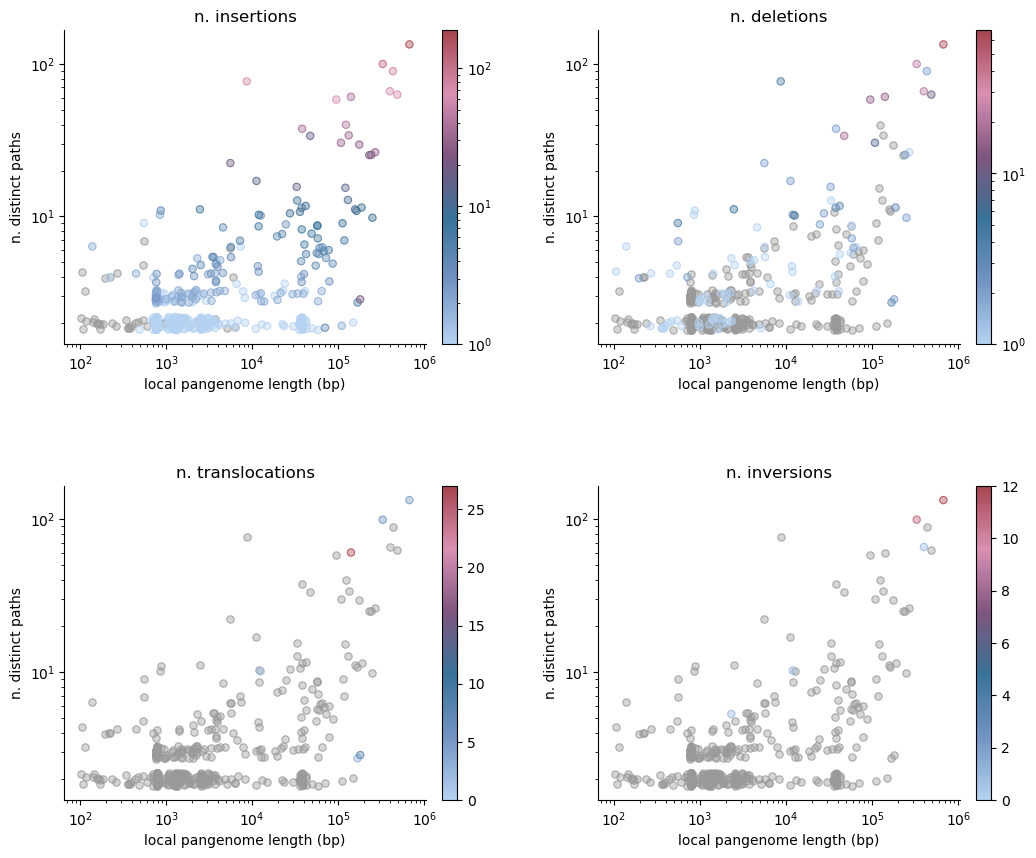

In [23]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_counts,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count=["n_insertion", "n_deletion", "n_translocation", "n_inversion"],  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.4,
      edge_alpha=0.8,
      log_color_scale=['n_insertion', 'n_deletion'],
      subplot_arrangement=(2, 2),
      figsize=(11, 10),
      shared_colorbar=False
  ) 

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:1893: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



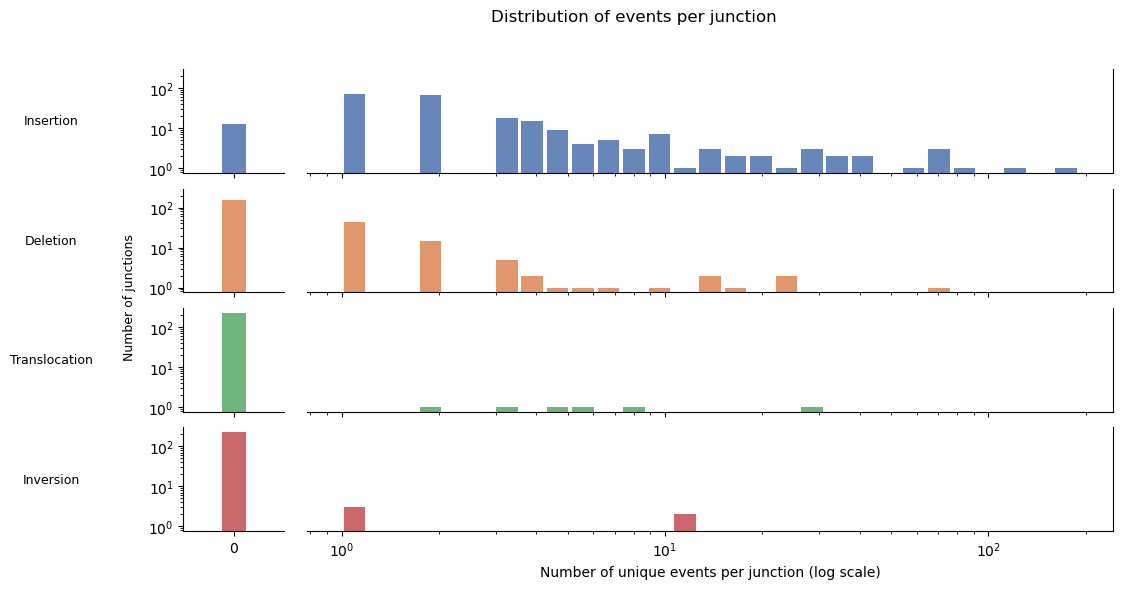

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:1893: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



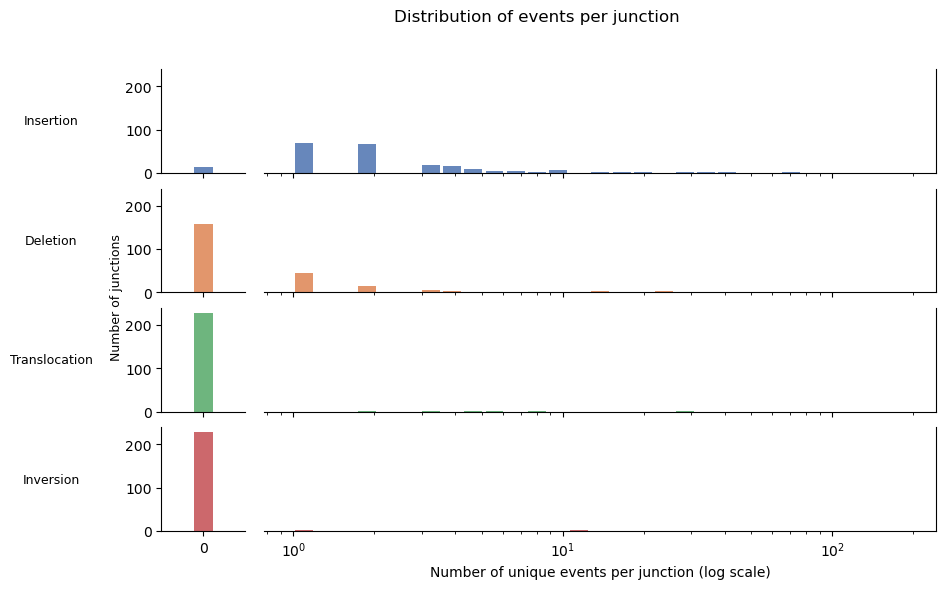

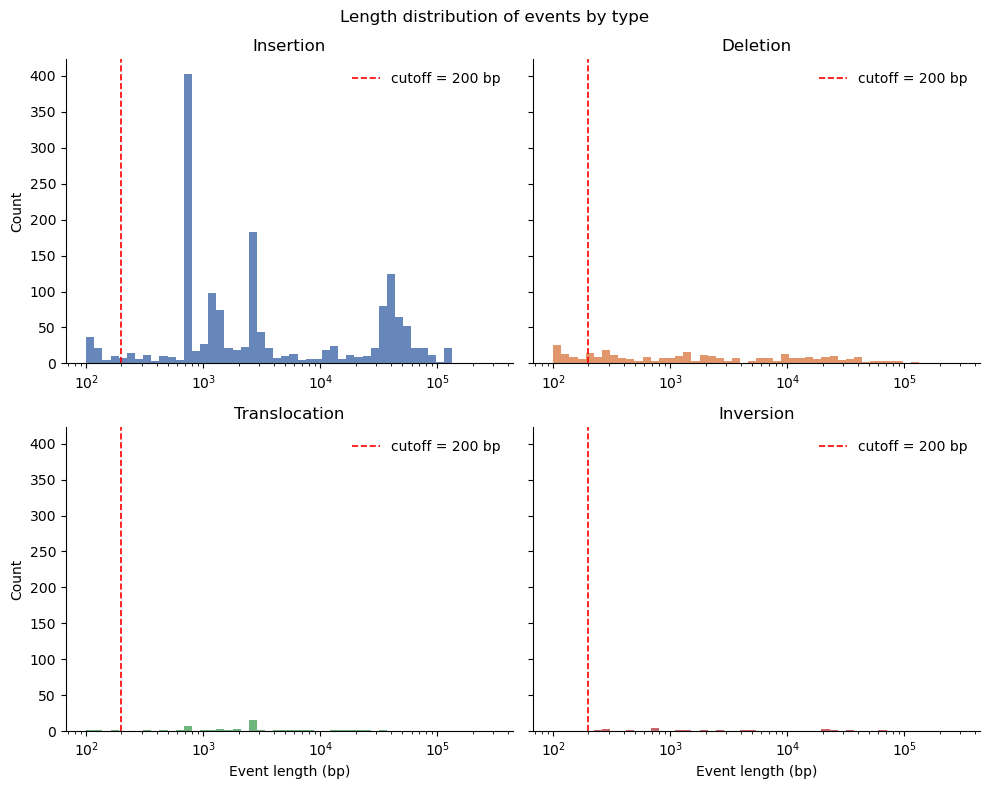

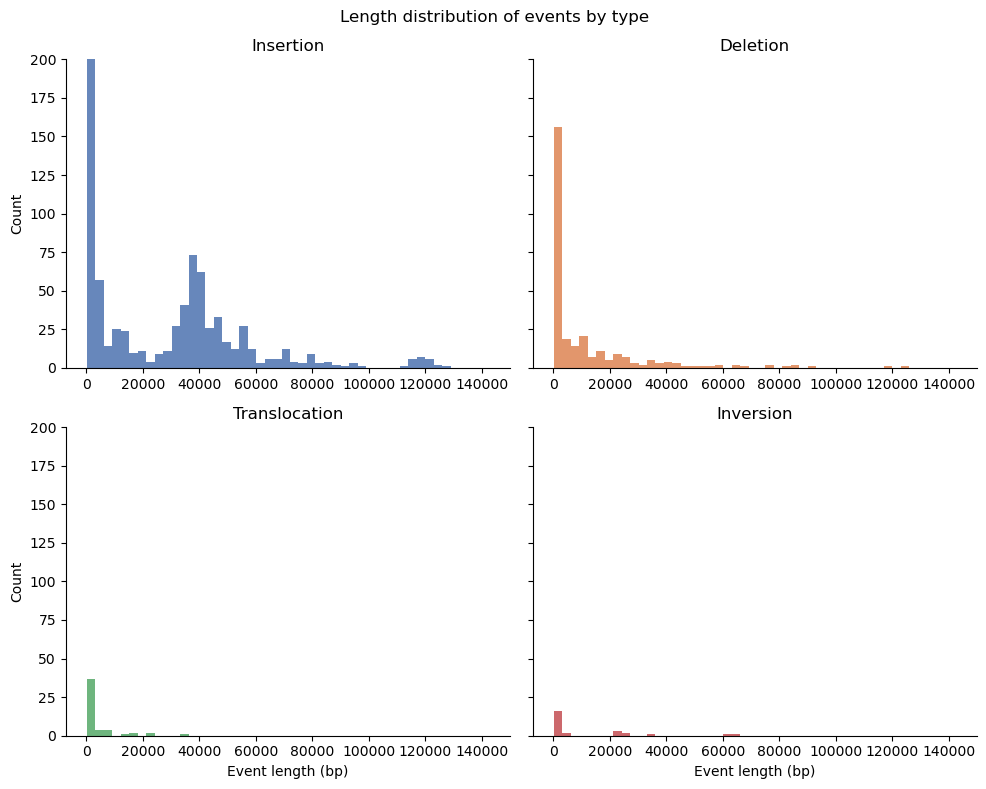

In [16]:
# only look at higher complexity junctions, that not just have one single insertion or deletion event, those have already been described in Marcos paper

non_singleton_junctions = jdf[jdf['singleton'] == False].edge.tolist()                                                                                                                                             
counts_df_ns = counts_df[counts_df['junction_name'].isin(non_singleton_junctions)]                                                                                                                                    
summary_df_ns = summary_df[summary_df['junction_name'].isin(non_singleton_junctions)]

plot_event_counts_distribution(counts_df_ns, figsize=(12, 6), log_x = True, log_y = True, subplots = True)
plot_event_counts_distribution(counts_df_ns, figsize=(10, 6), log_x = True, log_y = False, subplots = True)

plot_event_length_distribution(summary_df_ns, min_length_threshold=200, log_y = False, log_x=True)
plot_event_length_distribution(summary_df_ns, min_length_threshold=200, log_y = False, log_x=False, y_max = 200, x_max = 150000, filter_below_threshold=True)

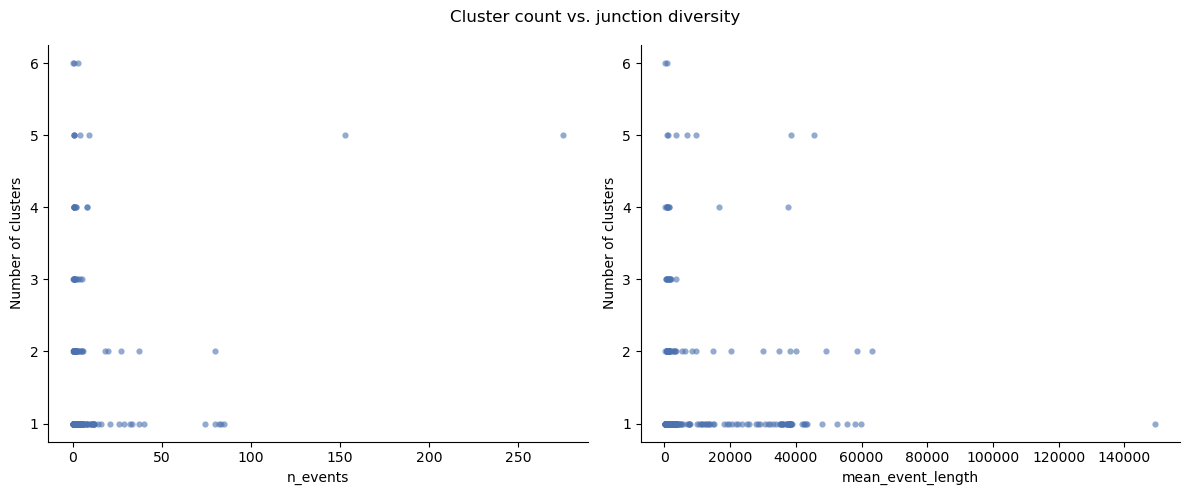

In [17]:
merged = jdf.merge(counts_df, left_on="edge", right_on="junction_name", how="left")                                                                                                                       
plot_cluster_count_vs_diversity(cluster_df_filtered, merged, diversity_columns=["n_events", "mean_event_length"], figsize=(12, 5))

We observe junctions with many events happening (many mge), but no homologous recombination, all three are interesting junctions
- EJPOGALASQ_f__KUIFCLFQSI_r: looks like just many mges / events
- GPKQYOCEJI_r__NKVSUZGURN_f: one can structurally see clusters of paths which are not declared as homologous recombinations, maybe should be? Interesting junction to compare structural clusters with core block clusters
- IHKFSQQUKE_r__KPBYGJHRZJ_f: has two long / only one prophage insertions in some isolates and sprinkled diversity on top, seems to be correct that there was no homologous recombination

In [18]:
all_merged = merged.copy().merge(cluster_df[["junction_name", "n_clusters"]], on="junction_name", how="left") 

In [19]:
all_merged.sort_values("n_events", ascending=False).head(20)

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,n_deletion,n_translocation,n_inversion,n_events,mean_length_insertion,mean_length_deletion,mean_length_translocation,mean_length_inversion,mean_event_length,n_clusters
532,XXVMWZCEKI_r__YUOECYBHUS_r,219,323,True,134,28,False,4.403688,18845,31533,...,69.0,5.0,12.0,275.0,6357.380952,19942.608696,1008.200000,5468.500000,9629.992727,5.0
534,RYYAQMEJGY_r__ZTHKZYHPIX_f,216,177,True,109,34,False,3.995602,12845,20375,...,22.0,6.0,11.0,153.0,3605.982456,16993.863636,7697.833333,21022.818182,6943.692810,5.0
478,EJPOGALASQ_f__KUIFCLFQSI_r,222,141,True,65,128,False,2.285007,3601,52321,...,22.0,0.0,1.0,85.0,9264.258065,21844.636364,NaN,246.000000,12414.258824,1.0
416,GPKQYOCEJI_r__NKVSUZGURN_f,222,92,True,53,69,False,2.688294,3518,9994,...,15.0,0.0,0.0,83.0,2390.367647,6397.000000,NaN,NaN,3114.457831,1.0
525,IHKFSQQUKE_r__KPBYGJHRZJ_f,220,214,True,83,49,False,3.550143,6146,80993,...,2.0,0.0,0.0,82.0,32432.037500,25810.000000,NaN,NaN,32270.524390,1.0
523,IFRPFFEGON_r__TCWDRAKLPS_r,220,90,True,58,46,False,3.028417,3778,15781,...,15.0,27.0,0.0,80.0,2966.736842,5449.866667,5865.925926,NaN,4410.800000,1.0
533,JVNRLCFAVD_f__PLTCZQCVRD_r,218,254,True,68,89,False,2.777543,6502,68292,...,10.0,0.0,0.0,80.0,64321.128571,18352.100000,NaN,NaN,58575.000000,2.0
5,JJRRWBDVGH_f__TFKJQKVUKX_f,222,26,True,70,30,False,3.451684,2035,19236,...,4.0,0.0,0.0,74.0,2594.900000,2176.000000,NaN,NaN,2572.256757,1.0
521,KYQOKYBCOW_r__XXIWNZXZTK_r,220,80,True,41,72,False,2.348591,2207,42558,...,0.0,0.0,0.0,40.0,52390.550000,NaN,NaN,NaN,52390.550000,1.0
505,XFUKGTZLAV_f__YBWQKVQGZE_f,221,40,True,37,122,False,1.937698,1231,24829,...,2.0,0.0,0.0,37.0,1611.800000,17448.500000,NaN,NaN,2467.837838,1.0


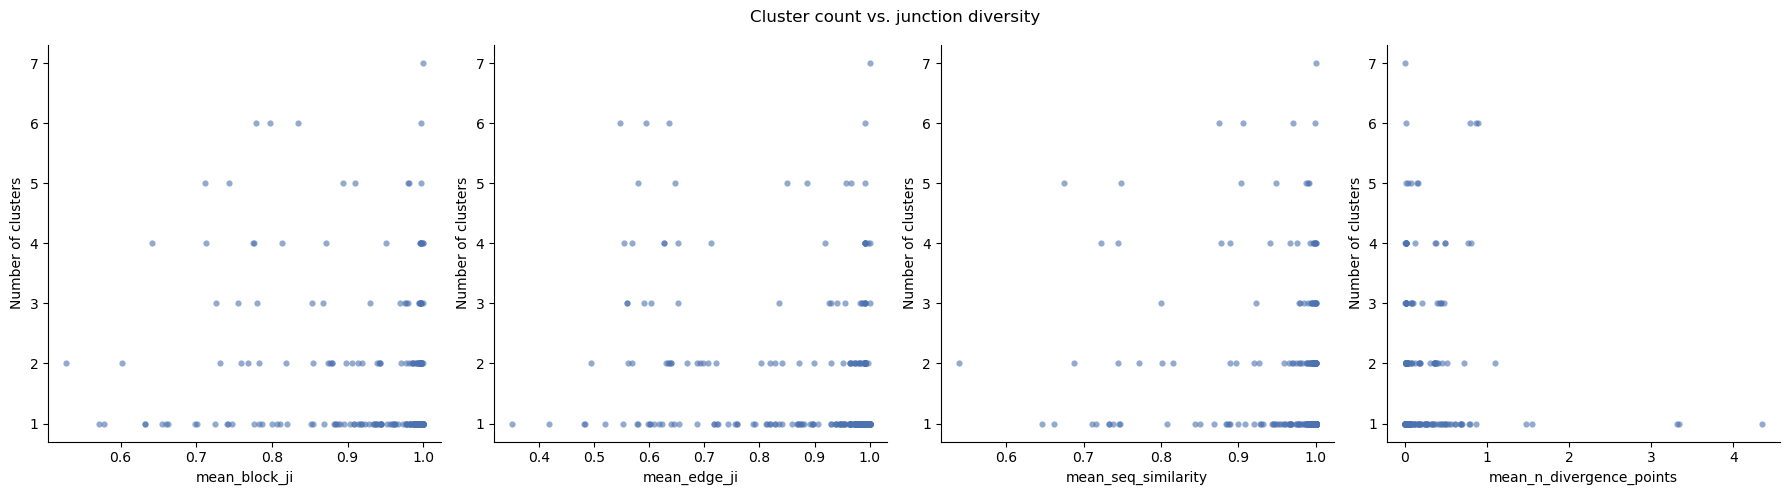

In [20]:
ji_df = pd.read_csv("../results/consensus_analysis/mean_diversity_per_junction.csv")
merged_ji = jdf.merge(ji_df, left_on="edge", right_on="junction_name", how="left")   
plot_cluster_count_vs_diversity(cluster_df_filtered, merged_ji, diversity_columns=["mean_block_ji", "mean_edge_ji", "mean_seq_similarity", "mean_n_divergence_points"], figsize=(18, 5))

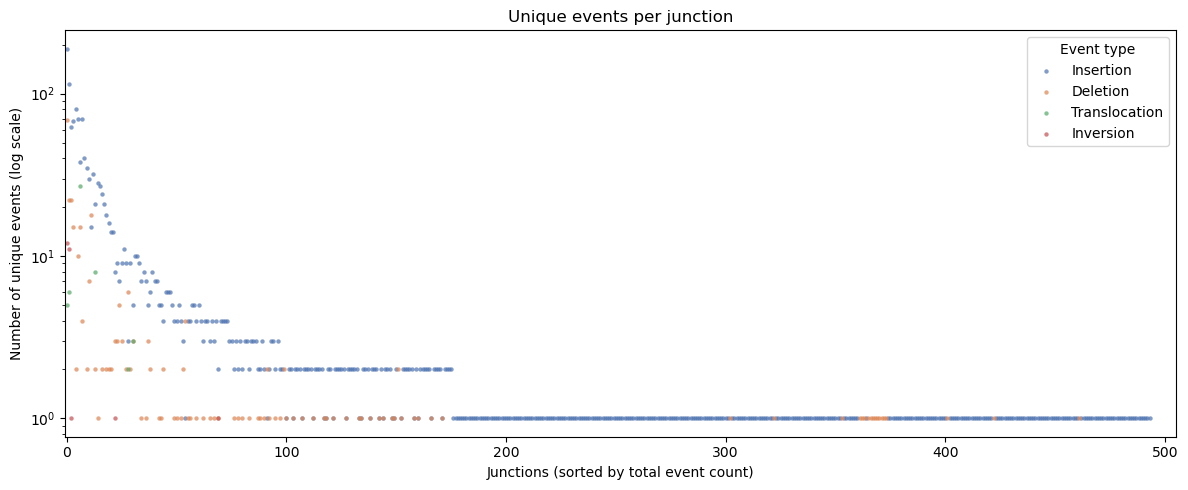

In [21]:
plot_events_per_junction(counts_df)

In [22]:
merged.sort_values("n_events", ascending=False).head(20)

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,n_insertion,n_deletion,n_translocation,n_inversion,n_events,mean_length_insertion,mean_length_deletion,mean_length_translocation,mean_length_inversion,mean_event_length
532,XXVMWZCEKI_r__YUOECYBHUS_r,219,323,True,134,28,False,4.403688,18845,31533,...,189.0,69.0,5.0,12.0,275.0,6357.380952,19942.608696,1008.200000,5468.500000,9629.992727
534,RYYAQMEJGY_r__ZTHKZYHPIX_f,216,177,True,109,34,False,3.995602,12845,20375,...,114.0,22.0,6.0,11.0,153.0,3605.982456,16993.863636,7697.833333,21022.818182,6943.692810
478,EJPOGALASQ_f__KUIFCLFQSI_r,222,141,True,65,128,False,2.285007,3601,52321,...,62.0,22.0,0.0,1.0,85.0,9264.258065,21844.636364,NaN,246.000000,12414.258824
416,GPKQYOCEJI_r__NKVSUZGURN_f,222,92,True,53,69,False,2.688294,3518,9994,...,68.0,15.0,0.0,0.0,83.0,2390.367647,6397.000000,NaN,NaN,3114.457831
525,IHKFSQQUKE_r__KPBYGJHRZJ_f,220,214,True,83,49,False,3.550143,6146,80993,...,80.0,2.0,0.0,0.0,82.0,32432.037500,25810.000000,NaN,NaN,32270.524390
523,IFRPFFEGON_r__TCWDRAKLPS_r,220,90,True,58,46,False,3.028417,3778,15781,...,38.0,15.0,27.0,0.0,80.0,2966.736842,5449.866667,5865.925926,NaN,4410.800000
533,JVNRLCFAVD_f__PLTCZQCVRD_r,218,254,True,68,89,False,2.777543,6502,68292,...,70.0,10.0,0.0,0.0,80.0,64321.128571,18352.100000,NaN,NaN,58575.000000
5,JJRRWBDVGH_f__TFKJQKVUKX_f,222,26,True,70,30,False,3.451684,2035,19236,...,70.0,4.0,0.0,0.0,74.0,2594.900000,2176.000000,NaN,NaN,2572.256757
521,KYQOKYBCOW_r__XXIWNZXZTK_r,220,80,True,41,72,False,2.348591,2207,42558,...,40.0,0.0,0.0,0.0,40.0,52390.550000,NaN,NaN,NaN,52390.550000
505,XFUKGTZLAV_f__YBWQKVQGZE_f,221,40,True,37,122,False,1.937698,1231,24829,...,35.0,2.0,0.0,0.0,37.0,1611.800000,17448.500000,NaN,NaN,2467.837838


What I found out about junction pangraphs:
- core definition is decided from first pangraph run (not rerun based on junctions), that's why rarely blocks can be present in all isolates but not core if a junction doesnt contain all isolates
- some junctions have more than 2 flanking core blocks (some have 3, 4, 5, or 6 and some have only 1, always at least 1)
- core blocks are never inverted, I think

for junction_id in jdf["edge"].tolist():
    pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_id}.json")
    bs_df = pangraph.to_blockstats_df()
    n_core = len(bs_df[bs_df['core'] == True])
    if n_core != 2:
        print(junction_id, n_core)

# 114 junctions have not exactly 2 core blocks (some have 3, 4, 5, or 6 and some have only 1, always at least 1)